# Explicabilidad del Modelo (XAI)

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import shap
import lime
import lime.lime_tabular
import dice_ml
from dice_ml import Dice

np.random.seed(42)

PALETTE = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
NOMBRES = {0: 'Piedra', 1: 'Tijera', 2: 'Papel', 3: 'Ok'}
SENSOR_COLS = [str(i) for i in range(64)]

import os
os.makedirs('plots', exist_ok=True)

## 2. Carga de datos y entrenamiento del modelo

In [2]:
df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)
df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

X = df.iloc[:, :64]
y = df.iloc[:, 64]
X.columns = [str(i) for i in range(64)]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución test: {y_test.value_counts().sort_index().to_dict()}")

Train: (9342, 64) | Test: (2336, 64)
Distribución test: {0: 582, 1: 581, 2: 589, 3: 584}


In [3]:
mejorparametros = {
    'n_estimators': 99,
    'num_leaves': 15,
    'min_child_samples': 3,
    'learning_rate': np.float64(0.17402065726724145),
    'log_max_bin': 8,
    'colsample_bytree': np.float64(0.6649148062238498),
    'reg_alpha': 0.0009765625,
    'reg_lambda': np.float64(0.006761362450996487),
    'random_state': 42,
    'verbose': -1
}

model = LGBMClassifier(**mejorparametros)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(
    y_test, y_pred,
    target_names=[NOMBRES[i] for i in range(4)]
))

              precision    recall  f1-score   support

      Piedra       0.98      0.99      0.99       582
      Tijera       0.97      0.96      0.97       581
       Papel       0.95      0.94      0.95       589
          Ok       0.94      0.95      0.94       584

    accuracy                           0.96      2336
   macro avg       0.96      0.96      0.96      2336
weighted avg       0.96      0.96      0.96      2336



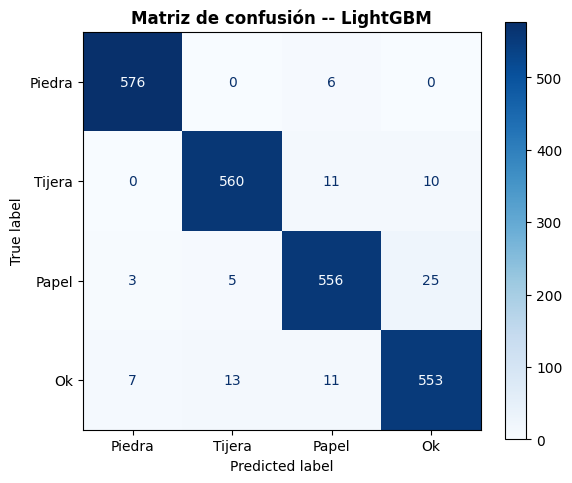

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=list(NOMBRES.values()),
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de confusión -- LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/xai_00_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. SHAP

In [5]:
explainer_shap = shap.TreeExplainer(model)

# Calculamos sobre tod0 el test set
shap_values = explainer_shap.shap_values(X_test)

# shap_values es una lista de 4 arrays (uno por clase): shape (n_test, 64)
print(f"Shape shap_values[0]: {shap_values[0].shape}")
print(f"Clases: {list(NOMBRES.values())}")

Shape shap_values[0]: (64, 4)
Clases: ['Piedra', 'Tijera', 'Papel', 'Ok']


In [6]:
shap_values_raw = explainer_shap.shap_values(X_test)
# shape: (2336, 64, 4) → convertir a lista de 4 arrays (2336, 64)
shap_values = [shap_values_raw[:, :, c] for c in range(4)]
print([sv.shape for sv in shap_values])

[(2336, 64), (2336, 64), (2336, 64), (2336, 64)]


### 3.1 SHAP — Importancia global (todas las clases)

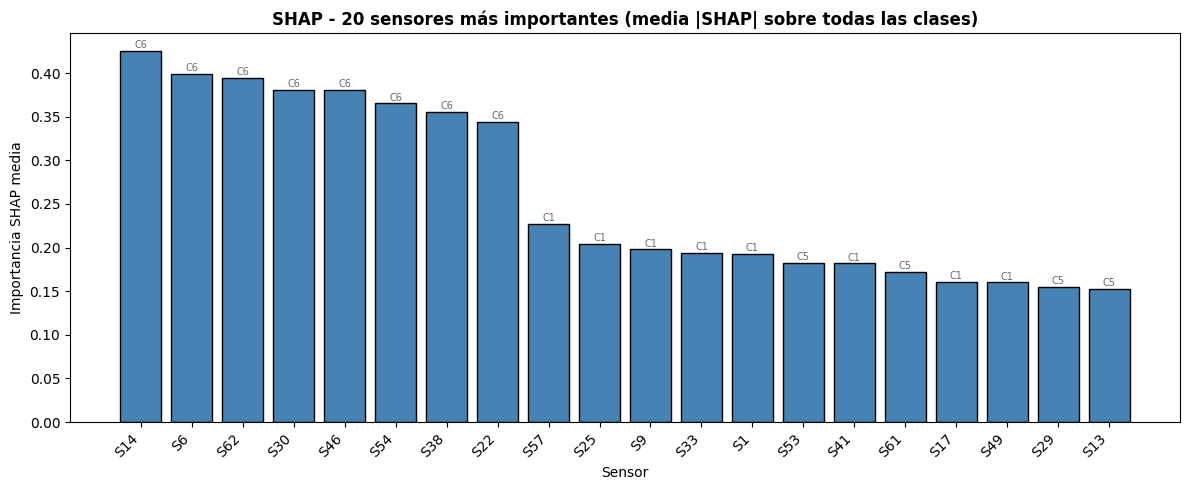

In [7]:
importancia_global = np.mean([np.abs(shap_values[c]).mean(axis=0) for c in range(4)], axis=0)
top_idx = np.argsort(importancia_global)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    range(20),
    importancia_global[top_idx],
    color='steelblue', edgecolor='black'
)
ax.set_xticks(range(20))
ax.set_xticklabels([f'S{i}' for i in top_idx], rotation=45, ha='right')
ax.set_title('SHAP - 20 sensores más importantes (media |SHAP| sobre todas las clases)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Importancia SHAP media')
ax.set_xlabel('Sensor')


for bar, idx in zip(bars, top_idx):
    canal = idx % 8
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'C{canal}', ha='center', va='bottom', fontsize=7, color='dimgray')

plt.tight_layout()
plt.savefig('plots/xai_01_shap_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Sumatorio por clase

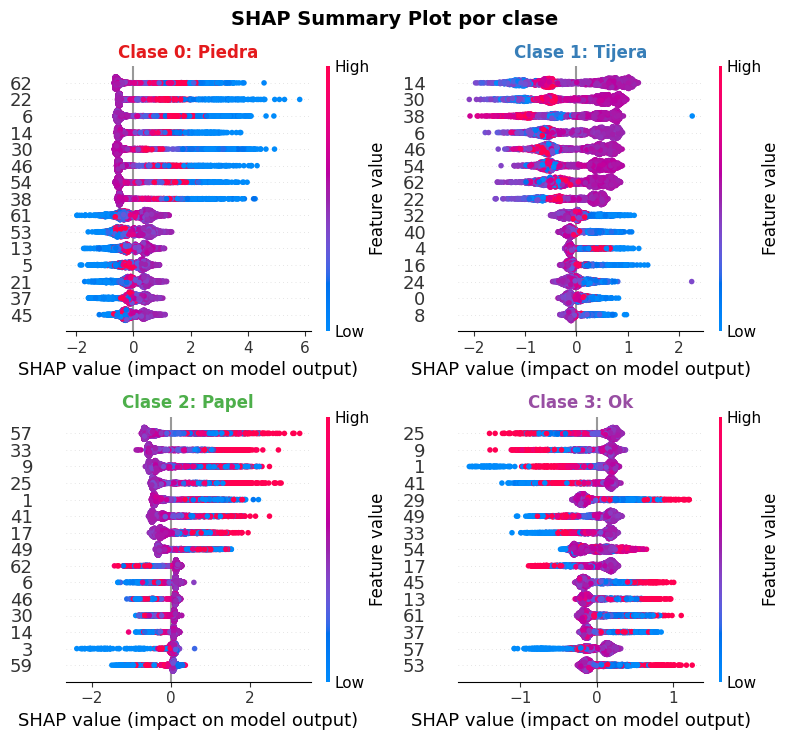

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP Summary Plot por clase', fontsize=14, fontweight='bold')

for clase in range(4):
    ax = axes[clase // 2, clase % 2]
    plt.sca(ax)
    shap.summary_plot(
        shap_values[clase],
        X_test,
        max_display=15,
        show=False,
        plot_type='dot',
        color_bar=True
    )
    ax.set_title(f'Clase {clase}: {NOMBRES[clase]}', fontsize=12, fontweight='bold',
                 color=PALETTE[clase])

plt.tight_layout()
plt.savefig('plots/xai_02_shap_summary_clases.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 Heatmap

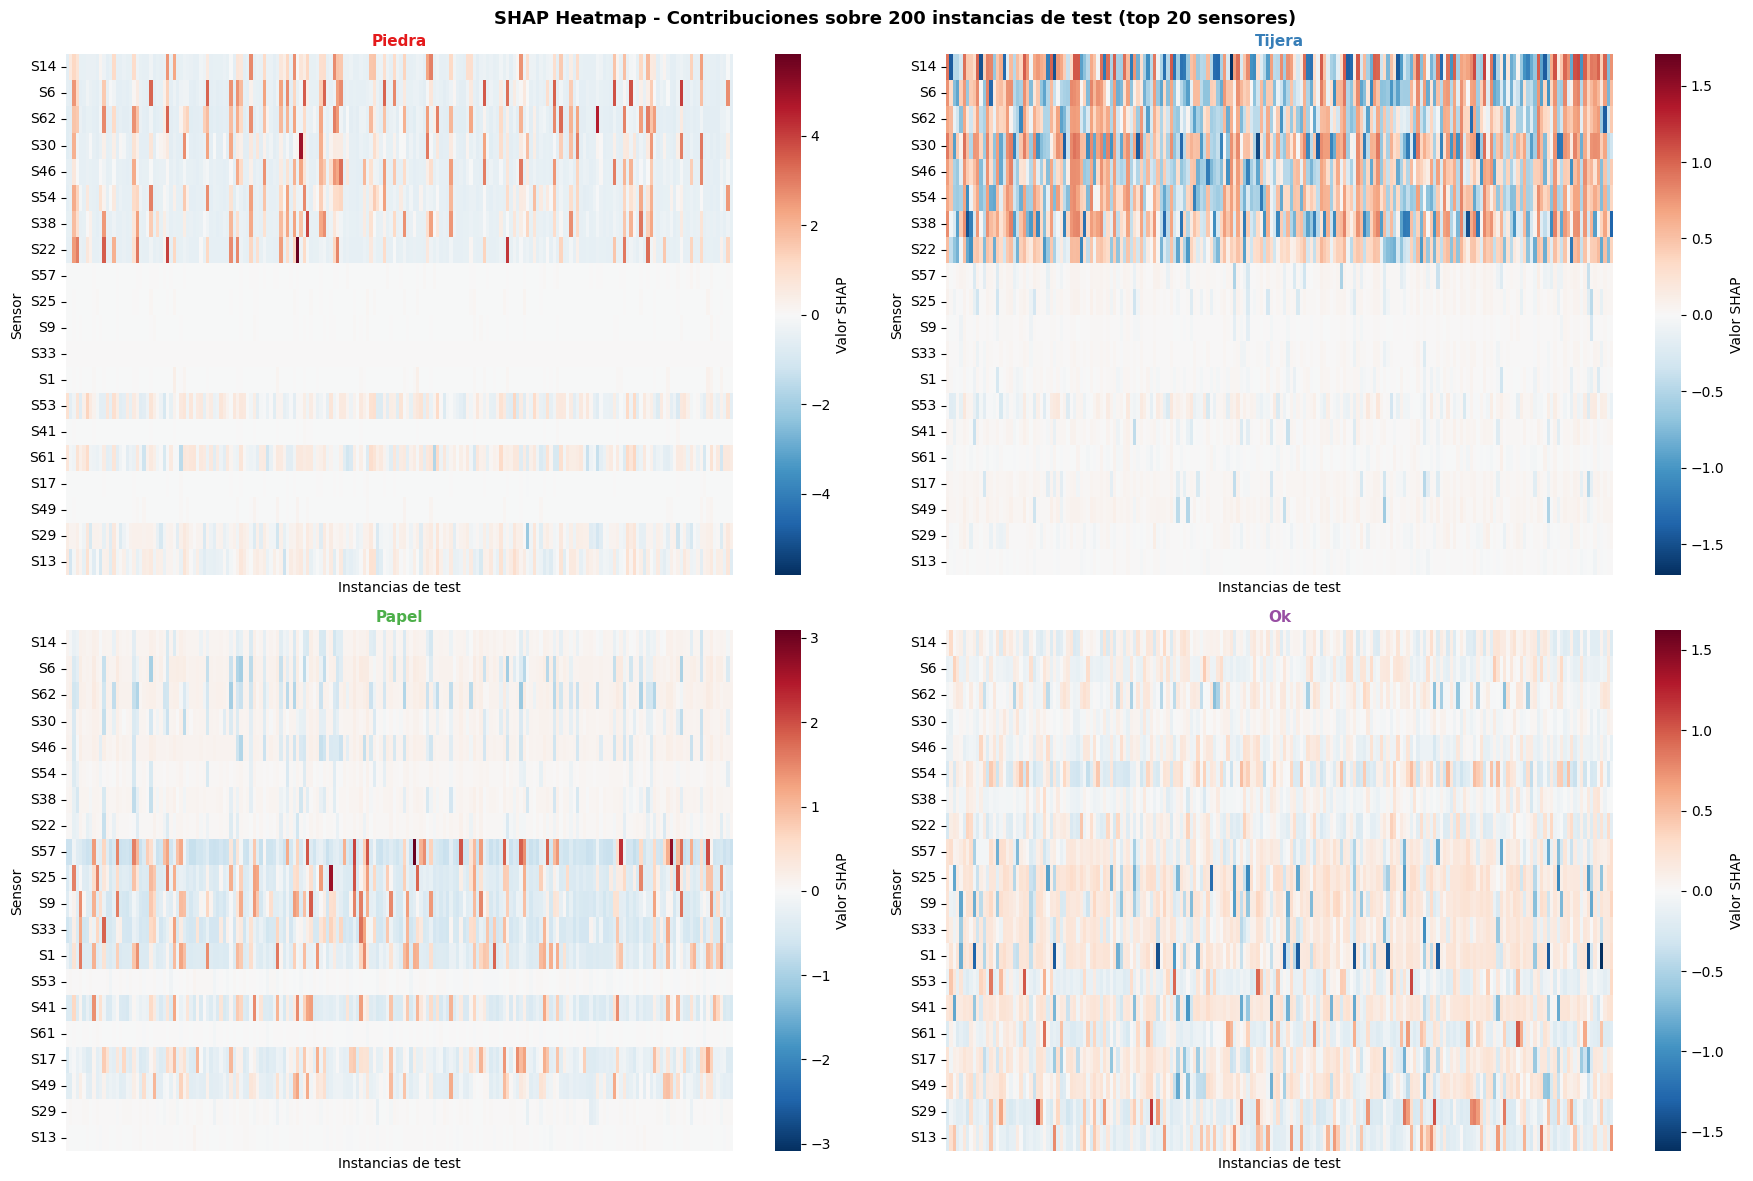

In [9]:
n_muestra = 200
idx_muestra = np.random.choice(len(X_test), n_muestra, replace=False)

# Top 20 sensores globales
top20 = np.argsort(importancia_global)[::-1][:20]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SHAP Heatmap - Contribuciones sobre 200 instancias de test (top 20 sensores)',
             fontsize=13, fontweight='bold')

for clase in range(4):
    ax = axes[clase // 2, clase % 2]
    sv_sub = shap_values[clase][idx_muestra][:, top20]
    vmax = np.abs(sv_sub).max()
    sns.heatmap(
        sv_sub.T,
        ax=ax,
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        center=0,
        yticklabels=[f'S{i}' for i in top20],
        xticklabels=False,
        cbar_kws={'label': 'Valor SHAP'}
    )
    ax.set_title(f'{NOMBRES[clase]}', fontsize=11, fontweight='bold', color=PALETTE[clase])
    ax.set_xlabel('Instancias de test')
    ax.set_ylabel('Sensor')

plt.tight_layout()
plt.savefig('plots/xai_05_shap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()